In [1]:
import pandas as pd

real_data = pd.read_csv(
    "../../data/processed/credit_default_clean.csv"
)

synthetic_data = pd.read_csv(
    "../../data/synthetic/credit_default_synthetic.csv"
)

In [3]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata.load_from_json(
    "../../reports/metadata/credit_default_metadata.json"
)

In [4]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 24/24 [00:00<00:00, 196.87it/s]|
Column Shapes Score: 83.62%

(2/2) Evaluating Column Pair Trends: |██████████| 276/276 [00:01<00:00, 175.07it/s]|
Column Pair Trends Score: 80.94%

Overall Score (Average): 82.28%



In [5]:
quality_report.get_score()

np.float64(0.8227751834206194)

In [6]:
quality_report.get_properties()

,Property,Score
0,Column Shapes,0.836185
1,Column Pair Trends,0.809365


In [7]:
report_dict = quality_report.get_properties()

report_dict.to_csv(
    "../../reports/credit_default_quality_report.csv",
    index=False
)

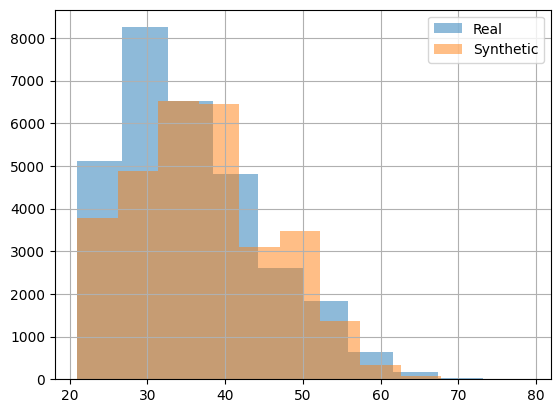

In [8]:
import matplotlib.pyplot as plt

real_data["AGE"].hist(alpha=0.5)
synthetic_data["AGE"].hist(alpha=0.5)

plt.legend(["Real","Synthetic"])
plt.show()